In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def _setup_grid(ax):
    """Set up 16x16 grid with cell-boundary lines."""
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(15.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks([i - 0.5 for i in range(17)], minor=False)
    ax.set_xticklabels([])
    ax.set_xticks(range(16), minor=True)
    ax.set_xticklabels([str(i) for i in range(16)], minor=True)
    ax.set_yticks([i - 0.5 for i in range(17)], minor=False)
    ax.set_yticklabels([])
    ax.set_yticks(range(16), minor=True)
    ax.set_yticklabels([str(i) for i in range(16)], minor=True)
    ax.tick_params(which='major', length=0)
    ax.tick_params(which='minor', length=0, labelsize=5)
    ax.grid(True, which='major', linewidth=0.3, color='#cccccc')
    
# ===== CONFIGURE HERE =====
TRACE_ENV_ID = 13
# ==========================

# Load from viz_data.pkl
with open('data_gen/viz_data.pkl', 'rb') as f:
    viz_data = pickle.load(f)

env_data = viz_data[TRACE_ENV_ID]
grid_env = env_data['grid_env']
state = env_data['state']
all_plans = env_data['plans']

# Separate by category
complete_plans = [p for p in all_plans if p['category'] == 'complete']
intermediate_plans = [p for p in all_plans if p['category'] == 'intermediate']

# Find lineage: ancestor plans whose nodes are a subset of the complete plan
complete_data = complete_plans[0]
complete_nodes = set(complete_data['plan'].g.nodes())

ancestor_plans = [p for p in intermediate_plans
                  if set(p['plan'].g.nodes()) <= complete_nodes]

# Deduplicate by node set (keep earliest iteration)
seen = {}
for pd in ancestor_plans:
    key = frozenset(pd['plan'].g.nodes())
    if key not in seen or pd['iteration'] < seen[key]['iteration']:
        seen[key] = pd
ancestors = sorted(seen.values(), key=lambda pd: (len(pd['plan'].g.nodes()), pd['iteration']))
ancestors.append(complete_data)

print(f'Env {TRACE_ENV_ID}: {len(intermediate_plans)} intermediate plans, '
      f'{len(complete_plans)} complete plan(s)')
print(f'Lineage: {len(ancestors)} steps from initial to complete\n')

for i, pd in enumerate(ancestors):
    plan = pd['plan']
    n_open = sum(1 for _,_,d in plan.g.edges(data=True) if d.get('status') == 'open')
    n_fixed = sum(1 for _,_,d in plan.g.edges(data=True) if d.get('status') == 'fixed')
    subgoals = [n for n in plan.g.nodes() if plan.g.nodes[n].get('ntype') == 'subgoal']
    new_sg = ''
    if i > 0:
        prev_nodes = set(ancestors[i-1]['plan'].g.nodes())
        added = set(plan.g.nodes()) - prev_nodes
        added_sg = [n for n in added if plan.g.nodes[n].get('ntype') == 'subgoal']
        if added_sg:
            new_sg = f'  << NEW: {", ".join(added_sg)}'
    print(f'  Step {i}: iter={pd["iteration"]:3d}, {len(plan.g.nodes()):2d} nodes, '
          f'{n_open} open / {n_fixed} fixed edges, '
          f'subgoals={subgoals}{new_sg}')

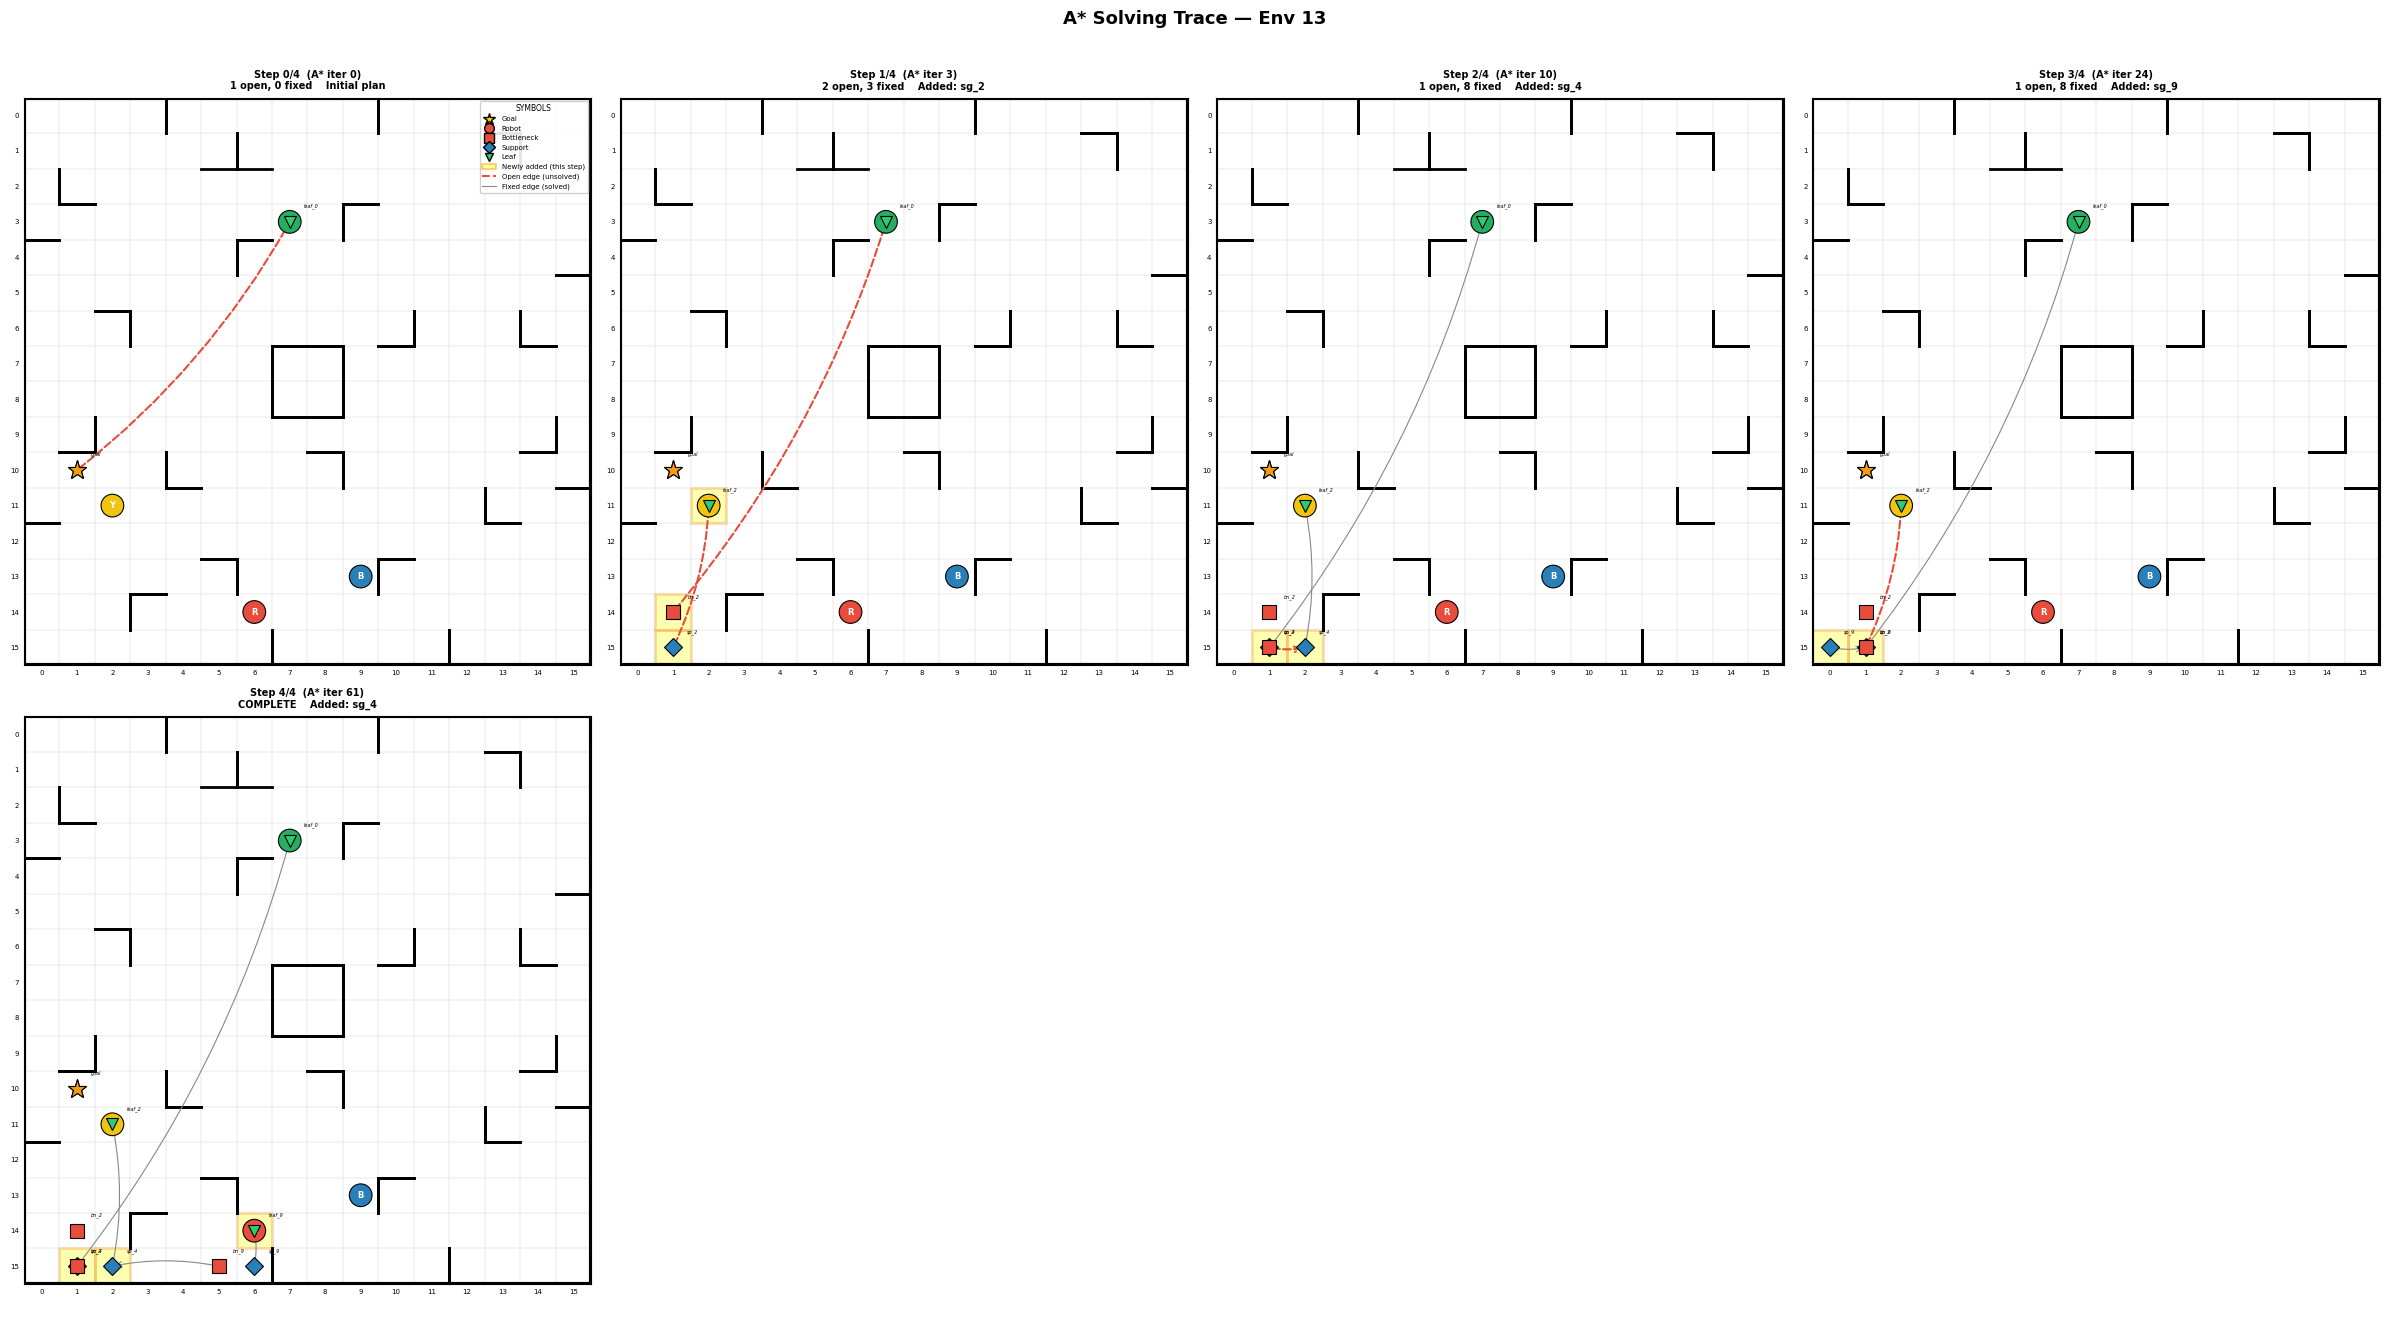

In [ ]:
ROBOT_COLORS = {'Red':'#e74c3c','Green':'#27ae60','Blue':'#2980b9','Yellow':'#f1c40f'}

def _draw_walls_from_env(ax, grid_env):
    """Draw walls from GridEnv grid_data."""
    gd = grid_env.grid_data
    for y in range(16):
        for x in range(16):
            idx = y * 16 + x
            cell = gd[idx] if gd and idx < len(gd) else 'X'
            if 'N' in cell and y > 0:
                ax.plot([x-0.5, x+0.5], [y-0.5, y-0.5], 'k-', lw=2)
            if 'S' in cell and y < 15:
                ax.plot([x-0.5, x+0.5], [y+0.5, y+0.5], 'k-', lw=2)
            if 'W' in cell and x > 0:
                ax.plot([x-0.5, x-0.5], [y-0.5, y+0.5], 'k-', lw=2)
            if 'E' in cell and x < 15:
                ax.plot([x+0.5, x+0.5], [y-0.5, y+0.5], 'k-', lw=2)
    for s in [[-0.5,15.5,-0.5,-0.5],[-0.5,15.5,15.5,15.5],
              [-0.5,-0.5,-0.5,15.5],[15.5,15.5,-0.5,15.5]]:
        ax.plot(s[:2], s[2:], 'k-', lw=3)


def draw_plan_step(ax, grid_env, state, plan_data, step_idx, total_steps,
                   prev_nodes=None):
    """Draw one step of the solving trace on ax."""
    plan = plan_data['plan']
    g = plan.g
    _setup_grid(ax)
    _draw_walls_from_env(ax, grid_env)

    # Goal
    gx, gy = state.target
    ax.plot(gx, gy, '*', ms=14, color='gold', mec='black', mew=0.8, zorder=5)

    # Robots
    for robot in [state.target_robot] + list(state.helpers):
        rx, ry = int(robot.position[0]), int(robot.position[1])
        fc = ROBOT_COLORS.get(robot.color, '#888')
        ax.add_patch(plt.Circle((rx, ry), 0.32, fc=fc, ec='black', lw=0.8, zorder=4))
        ax.text(rx, ry, robot.color[0], ha='center', va='center',
                fontsize=6, fontweight='bold', color='white', zorder=6)

    # Determine which nodes are new in this step
    current_nodes = set(g.nodes())
    new_nodes = current_nodes - prev_nodes if prev_nodes else set()

    # Draw edges
    for u, v, edata in g.edges(data=True):
        status = edata.get('status', 'fixed')
        u_data = g.nodes[u]
        v_data = g.nodes[v]
        if 'pos' in u_data and 'pos' in v_data:
            x0, y0 = int(u_data['pos'][0]), int(u_data['pos'][1])
            x1, y1 = int(v_data['pos'][0]), int(v_data['pos'][1])
            ls = '--' if status == 'open' else '-'
            ec = '#e74c3c' if status == 'open' else '#888'
            lw = 1.5 if status == 'open' else 0.8
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                       arrowprops=dict(arrowstyle='->', color=ec, lw=lw,
                                      linestyle=ls, connectionstyle='arc3,rad=0.1'),
                       zorder=2)

    # Draw plan nodes
    type_markers = {'goal':('*',14), 'bottleneck':('s',10), 'support':('D',9), 'leaf':('v',9)}
    type_colors_default = {'goal':'#f39c12', 'bottleneck':'#e74c3c', 'support':'#2980b9', 'leaf':'#2ecc71'}

    for nid, data in g.nodes(data=True):
        if 'pos' not in data:
            continue
        ntype = data['ntype']
        if ntype == 'subgoal':
            continue
        x, y = int(data['pos'][0]), int(data['pos'][1])
        marker, ms = type_markers.get(ntype, ('o', 8))
        fc = type_colors_default.get(ntype, '#888')

        # Highlight newly added nodes
        if nid in new_nodes:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                         fc='#ffff00', alpha=0.3, ec='#ff8800', lw=2, zorder=1))

        ax.plot(x, y, marker=marker, markersize=ms, color=fc,
                markeredgecolor='black', markeredgewidth=0.8, zorder=7)
        ax.text(x+0.4, y-0.4, nid, fontsize=3.5, color='black',
                zorder=8, fontstyle='italic')

    # Title
    n_open = sum(1 for _,_,d in g.edges(data=True) if d.get('status') == 'open')
    n_fixed = sum(1 for _,_,d in g.edges(data=True) if d.get('status') == 'fixed')
    category = plan_data.get('category', '?')
    label = 'COMPLETE' if category == 'complete' else f'{n_open} open, {n_fixed} fixed'

    new_sg = [n for n in new_nodes if g.nodes[n].get('ntype') == 'subgoal']
    subtitle = f'Added: {", ".join(new_sg)}' if new_sg else ('Initial plan' if step_idx == 0 else '')

    ax.set_title(f'Step {step_idx}/{total_steps-1}  (A* iter {plan_data["iteration"]})\n'
                 f'{label}    {subtitle}',
                 fontsize=7, fontweight='bold')


# --- Draw the trace ---
n_steps = len(ancestors)
ncols = min(4, n_steps)
nrows = (n_steps + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6.5*nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncols == 1:
    axes = axes[:, np.newaxis]

prev_nodes = set()
for i, pd in enumerate(ancestors):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    draw_plan_step(ax, grid_env, state, pd, i, n_steps, prev_nodes)
    prev_nodes = set(pd['plan'].g.nodes())

# Hide unused axes
for i in range(n_steps, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

# Legend on the first axes
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=9,
           markeredgecolor='black', label='Goal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=7,
           markeredgecolor='black', label='Robot'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e74c3c', markersize=7,
           markeredgecolor='black', label='Bottleneck'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#2980b9', markersize=6,
           markeredgecolor='black', label='Support'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='#2ecc71', markersize=6,
           markeredgecolor='black', label='Leaf'),
    mpatches.Patch(fc='#ffff00', alpha=0.4, ec='#ff8800', lw=1.5,
                   label='Newly added (this step)'),
    Line2D([0], [0], color='#e74c3c', lw=1.5, ls='--', label='Open edge (unsolved)'),
    Line2D([0], [0], color='#888', lw=0.8, label='Fixed edge (solved)'),
]
axes[0, 0].legend(handles=legend_elements, loc='upper right', fontsize=5,
                  framealpha=0.9, title='SYMBOLS', title_fontsize=5.5)

fig.suptitle(f'A* Solving Trace — Env {TRACE_ENV_ID}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()